In [1]:
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
import easyocr
import numpy as np
import fitz
import os

In [3]:
# Khởi tạo reader với tiếng Việt ('vi') và tiếng Anh ('en')
# gpu=True nếu máy có card rời, False nếu dùng CPU
reader = easyocr.Reader(['vi', 'en'], gpu=True)

In [ ]:
class UniversalReader:
    def __init__(self, languages=['vi', 'en'], gpu=True):
        print("Đang tải model EasyOCR...")
        self.reader = easyocr.Reader(languages, gpu=gpu)

    def read_file(self, file_path):
        """
        Hàm thông minh tự phát hiện loại file và xử lý
        """
        ext = os.path.splitext(file_path)[1].lower()
        
        if ext == '.pdf':
            return self._read_pdf(file_path)
        elif ext in ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']:
            return self._read_image(file_path)
        else:
            return f"Không hỗ trợ định dạng: {ext}"

    def _read_image(self, image_path):
        print(f"--> Đang xử lý ảnh: {os.path.basename(image_path)}")
        result = self.reader.readtext(image_path, detail=0)
        return " ".join(result)

    def _read_pdf(self, pdf_path):
        print(f"--> Đang xử lý PDF: {os.path.basename(pdf_path)}")
        full_text = ""
        
        try:
            doc = fitz.open(pdf_path)
            
            if len(doc) == 0:
                return "PDF có 0 trang."

            for page_num, page in enumerate(doc):
                mat = fitz.Matrix(2, 2) 
                pix = page.get_pixmap(matrix=mat)
                
                img_data = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.h, pix.w, pix.n)
                
                if pix.n == 4:
                    img_data = img_data[..., :3]

                result = self.reader.readtext(img_data, detail=0)
                
                page_text = " ".join(result)
                full_text += f"\n--- Trang {page_num + 1} ---\n{page_text}"
                print(f"Đã xong trang {page_num + 1}")
                
            doc.close()
            return full_text
            
        except Exception as e:
            return f"Lỗi xử lý PDF: {str(e)}"

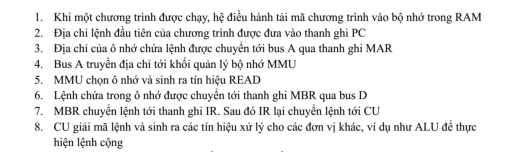

'1. Khi một chương trình được chạy; hệ điều hành tải mã chương trình vào bộ nhớ trong RAM 2 Địa chỉ lệnh đầu tiên của chương trình được đưa vào thanh ghi PC 3 . Địa chỉ của ô nhớ chứa lệnh được chuyển tới bus A qua thanh ghi MAR 4. Bus A truyền địa chỉ tới khối quản lý bộ nhớ MMU 5. MMU chọn ô nhớ và sinh ra tín hiệu READ 6. Lệnh chứa trong ô nhớ được chuyển tới thanh ghi MBR qua bus D 7 . MBR chuyển lệnh tới thanh ghi IR. Sau đó IR lại chuyển lệnh tới CU 8 CU mã lệnh và sinh ra các tín hiệu xử lý cho các đơn vị khác, ví dụ như ALU để thực hiện lệnh cộng giải'

In [ ]:
import numpy as np

img_path = 'Screenshot 2025-12-03 221126.png'

img = Image.open(img_path)
plt.imshow(img)
plt.axis('off')
plt.show()

result = reader.readtext(img_path)

texts = [text for (bbox, text, prob) in result]

" ".join(texts)

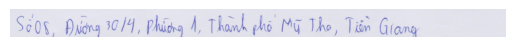

--- KẾT QUẢ ---
Scos {uong 36/4 , phucrq /, Thank ,ho' Mũ Tho Tián   Giiane


In [6]:
img_path = '../vn_handwritten_images/data/0788_samples.png'

img = Image.open(img_path)
img_np = np.array(img)

plt.imshow(img)
plt.axis('off')
plt.show()

result = reader.readtext(img_np, paragraph=True)

print("--- KẾT QUẢ ---")
for res in result:
    print(res[1])

In [7]:
my_ocr = UniversalReader()

pdf_path = "Các thành phần cơ bản của kiến trúc máy tính.pdf"
my_ocr.read_file(pdf_path)

Đang tải model EasyOCR...
--> Đang xử lý PDF: Các thành phần cơ bản của kiến trúc máy tính.pdf
Đã xong trang 1


'\n--- Trang 1 ---\nCác thành phần cơ bản của kiến trúc máy tính: Kiến trúc tập lệnh: Mô hình trừu tượng của máy tính ở mức ngôn ngữ máy (hợp ngữ) xác định những gì bộ xử lý thực hiện và cách thực hiện: Tập lệnh Các chế độ địa chỉ bộ nhớ Các thanh ghi Khuôn dạng địa chỉ và dữ liệu Vi kiến trúc: Là tổ chức máy tính, mô tả về hệ thống ở mức thấp, liên quan tới: Các thành phần cứng kết nối với nhau như thế nào Các thành phần phần cứng phối hợp, tương tác với nhau như thế nào để thực hiện tập Iệnh Thiết kế hệ thống: Bao gồm tất cả các thành cứng khác trong hệ máy tính: Các hệ thống kết nối như bus và chuyển mạch Mạch điều khiển bộ nhớ, cấu trúc phân cấp bộ nhớ Các kỹ thuật giảm tải cho CPU như truy cập trực tiếp bộ nhớ Các vấn đề như đa xử lý phần phần thống'

In [8]:
image_path = "Screenshot 2025-12-03 221126.png"
my_ocr.read_file(image_path)

--> Đang xử lý ảnh: Screenshot 2025-12-03 221126.png


'1. Khi một chương trình được chạy; hệ điều hành tải mã chương trình vào bộ nhớ trong RAM 2 Địa chỉ lệnh đầu tiên của chương trình được đưa vào thanh ghi PC 3 . Địa chỉ của ô nhớ chứa lệnh được chuyển tới bus A qua thanh ghi MAR 4. Bus A truyền địa chỉ tới khối quản lý bộ nhớ MMU 5. MMU chọn ô nhớ và sinh ra tín hiệu READ 6. Lệnh chứa trong ô nhớ được chuyển tới thanh ghi MBR qua bus D 7 . MBR chuyển lệnh tới thanh ghi IR. Sau đó IR lại chuyển lệnh tới CU 8 CU mã lệnh và sinh ra các tín hiệu xử lý cho các đơn vị khác, ví dụ như ALU để thực hiện lệnh cộng giải'

In [9]:
pdf_path = "signal.pdf"
my_ocr.read_file(pdf_path)

--> Đang xử lý PDF: signal.pdf
Đã xong trang 1


'\n--- Trang 1 ---\nCác thành phần cơ bản của kiến trúc máy tính: Kiến trúc tập lệnh: Mô hình trừu tượng của máy tính ở mức ngôn ngữ máy (hợp ngữ) xác định những gì bộ xử lý thực hiện và cách thực hiện: Tập lệnh Các chế độ địa chỉ bộ nhớ Các thanh ghi Khuôn dạng địa chỉ và dữ liệu Vi kiến trúc: Là tổ chức máy tính, mô tả về hệ thống ở mức thấp, liên quan tới: Các thành phần cứng kết nối với nhau như thế nào Các thành phần phần cứng phối tương tác với nhau như thế nào để thực hiện tập Iệnh Thiết kế hệ thống: Bao gồm tất cả các thành phần phần cứng khác trong hệ máy tính: Các hệ thống kết nối như bus và chuyển mạch Mạch điều khiển bộ nhớ, cấu trúc phân cấp bộ nhớ Các kỹ thuật giảm tải cho CPU như truy cập trực tiếp bộ nhớ Các vấn đề như đa xử lý hợp, thống'